In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel, Field


# Create a state schema
class AgentState(TypedDict):
    message: str
    name: str
    age: int


In [2]:
# Create a node
def message_node(state: AgentState) -> dict:
    message = state.get("message", "Default message")

    print(f"Initial State: {state}")

    return {
        "message": message,
        "age": 31
    }


In [3]:
# Create the Graph
graph = StateGraph(AgentState)

#Add nodes
graph.add_node("messenger", message_node)

graph.add_edge(START, "messenger")
graph.add_edge("messenger", END)

# Run the graph
workflow = graph.compile()

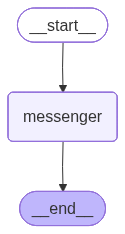

In [4]:
from IPython.display import  Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [5]:
# Invoke the graph
initState = {
    "message": "Welcome to LangGraph!",
    "name": "James",
    "age": 26
}
result = workflow.invoke(initState)

print(result)

Initial State: {'message': 'Welcome to LangGraph!', 'name': 'James', 'age': 26}
{'message': 'Welcome to LangGraph!', 'name': 'James', 'age': 31}
